# Machine Learning Showcase: Genre-Vorhersage mit Spotify-Daten

In diesem Notebook lernen wir, wie man mit Machine Learning das Genre eines Songs vorhersagen kann.

**Was wir lernen:**
- Wie man Daten für ML vorbereitet (Features vs. Zielvariable)
- Warum wir Trainings- und Testdaten trennen
- Wie ein Decision Tree funktioniert
- Wie wir die Qualität unseres Modells bewerten

## 1. Setup und Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Helpers importieren
sys.path.append('src')
from src.helpers import load_dataset, filter_data
from src.helpers.ml import (
    prepare_ml_data, 
    split_data, 
    train_model,
    evaluate_model, 
    predict,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_decision_tree
)

# Spotify-Daten laden
spotify = load_dataset('spotify')
print(f"Datensatz geladen: {spotify.shape[0]} Songs, {spotify.shape[1]} Spalten")
spotify.head()

Datensatz geladen: 18679 Songs, 21 Spalten


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Daten filtern

Wir fokussieren uns auf 4 Genres, um das Problem einfacher zu machen. Mit zu vielen Genres wird die Vorhersage schwieriger.

In [2]:
# Welche Genres gibt es?
print("Verfügbare Genres:")
print(spotify['track_genre'].value_counts().head(20))

Verfügbare Genres:
track_genre
pop-film             740
chill                699
k-pop                583
hip-hop              508
deep-house           500
ambient              495
anime                479
british              475
emo                  440
grunge               424
acoustic             398
mandopop             384
piano                357
progressive-house    350
spanish              344
indian               335
alt-rock             335
garage               329
edm                  329
electronic           313
Name: count, dtype: int64


In [23]:
# 4 unterschiedliche Genres auswaehlen
selected_genres = ['pop-film', 'chill', 'k-pop', 'hip-hop']

spotify_ml = filter_data(spotify, track_genre=selected_genres)
print(f"Gefiltert auf {len(spotify_ml)} Songs")
print(f"\nGenre-Verteilung:")
print(spotify_ml['track_genre'].value_counts())

Gefiltert auf 2530 Songs

Genre-Verteilung:
track_genre
pop-film    740
chill       699
k-pop       583
hip-hop     508
Name: count, dtype: int64


## 3. Features und Zielvariable definieren

**Wichtige Konzepte:**
- **Features (X)**: Die Eigenschaften, die wir dem Modell geben (z.B. danceability, energy)
- **Zielvariable (y)**: Was wir vorhersagen wollen (hier: track_genre)

Das Modell lernt Muster in den Features, um die Zielvariable vorherzusagen.

In [24]:
# Features auswählen - das sind die Audio-Eigenschaften der Songs
feature_columns = ['danceability', 'energy', 'acousticness', 'valence', 
                   'tempo', 'speechiness', 'instrumentalness', 'liveness']

# Daten vorbereiten
X, y = prepare_ml_data(
    spotify_ml, 
    target='track_genre',
    features=feature_columns
)

print(f"\nFeatures (X): {X.shape}")
print(f"Zielvariable (y): {y.shape}")

Daten vorbereitet: 2530 Datensätze, 8 Features, Ziel: 'track_genre'

Features (X): (2530, 8)
Zielvariable (y): (2530,)


In [25]:
# Schauen wir uns die Features an
print("Beispiel-Daten (erste 5 Songs):")
X.head()

Beispiel-Daten (erste 5 Songs):


,danceability,energy,acousticness,valence,tempo,speechiness,instrumentalness,liveness
3141,0.456,0.437,0.839,0.2090,108.678,0.0867,0.00000,0.218
3142,0.603,0.204,0.479,0.7100,74.688,0.1120,0.07140,0.642
3143,0.543,0.206,0.940,0.1300,113.107,0.0319,0.45300,0.385
3144,0.550,0.147,0.563,0.0346,81.991,0.0404,0.00102,0.286
3145,0.550,0.143,0.956,0.2240,74.918,0.2410,0.00000,0.195


## 4. Train/Test Split

**Warum teilen wir die Daten?**

Stell dir vor, du lernst für eine Prüfung:
- **Trainingsdaten** = Die Übungsaufgaben, mit denen du lernst
- **Testdaten** = Die Prüfung selbst (neue, ungesehene Aufgaben)

Wenn du nur die Übungsaufgaben auswendig lernst, weisst du nicht, ob du das Thema wirklich verstanden hast. Genauso beim Modell: Wir testen es mit Daten, die es noch nie gesehen hat.

In [26]:
# Daten aufteilen: 80% Training, 20% Test
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)

print(f"\nTrainingsdaten: {len(X_train)} Songs")
print(f"Testdaten: {len(X_test)} Songs")

Daten aufgeteilt: Training: 2024 (80%), Test: 506 (20%)

Trainingsdaten: 2024 Songs
Testdaten: 506 Songs


## 5. Modell trainieren

Wir verwenden einen **Decision Tree** (Entscheidungsbaum).

**Wie funktioniert ein Decision Tree?**
- Der Baum stellt Fragen wie: "Ist die danceability > 0.7?"
- Je nach Antwort geht er einen anderen Zweig entlang
- Am Ende landet er bei einer Vorhersage (z.B. "hip-hop")

**max_depth** begrenzt, wie tief der Baum werden darf. Das verhindert "Overfitting" (zu genaues Auswendiglernen der Trainingsdaten).

In [27]:
# Decision Tree trainieren
model = train_model(X_train, y_train, model_type='decision_tree', max_depth=5)

Modell trainiert: Decision Tree (max_depth=5)


## 6. Modell bewerten

Jetzt testen wir, wie gut unser Modell ist - mit den Testdaten, die es noch nie gesehen hat!

In [28]:
# Modell auf Testdaten bewerten
results = evaluate_model(model, X_test, y_test)

Genauigkeit: 53.6% (53.6% der Songs wurden richtig klassifiziert)

Klassifikationsbericht:
              precision    recall  f1-score   support

       chill       0.73      0.65      0.69       140
     hip-hop       0.41      0.31      0.35       101
       k-pop       0.46      0.33      0.39       117
    pop-film       0.50      0.74      0.59       148

    accuracy                           0.54       506
   macro avg       0.53      0.51      0.51       506
weighted avg       0.54      0.54      0.52       506



### Was bedeutet die Genauigkeit?

- Bei 4 Genres waere **zufälliges Raten** etwa 25% genau
- Eine Genauigkeit von **50-70%** zeigt, dass das Modell etwas gelernt hat
- **80%+** wäre sehr gut für dieses Problem

## 7. Konfusionsmatrix visualisieren

Die **Konfusionsmatrix** zeigt, welche Genres wie oft verwechselt werden:
- Diagonale (von oben links nach unten rechts) = Richtige Vorhersagen
- Ausserhalb der Diagonale = Fehler

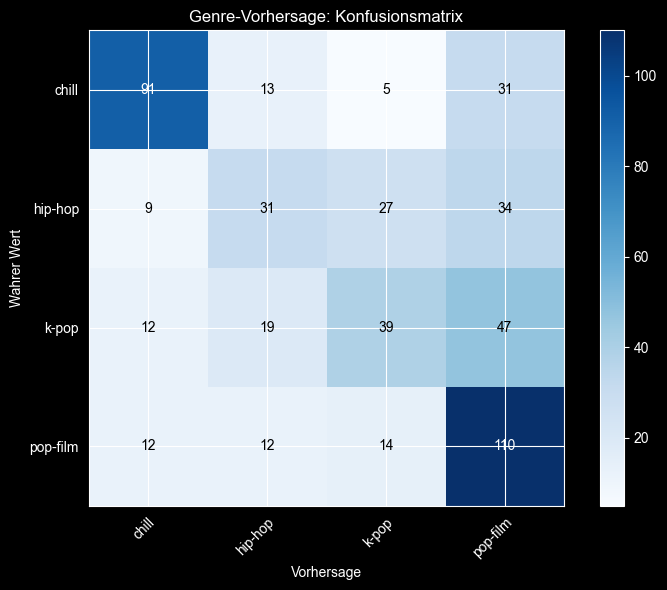

In [29]:
# Konfusionsmatrix anzeigen
plot_confusion_matrix(y_test, results['predictions'], title='Genre-Vorhersage: Konfusionsmatrix')

## 8. Feature-Wichtigkeit

Welche Audio-Eigenschaften sind am wichtigsten für die Genre-Vorhersage?

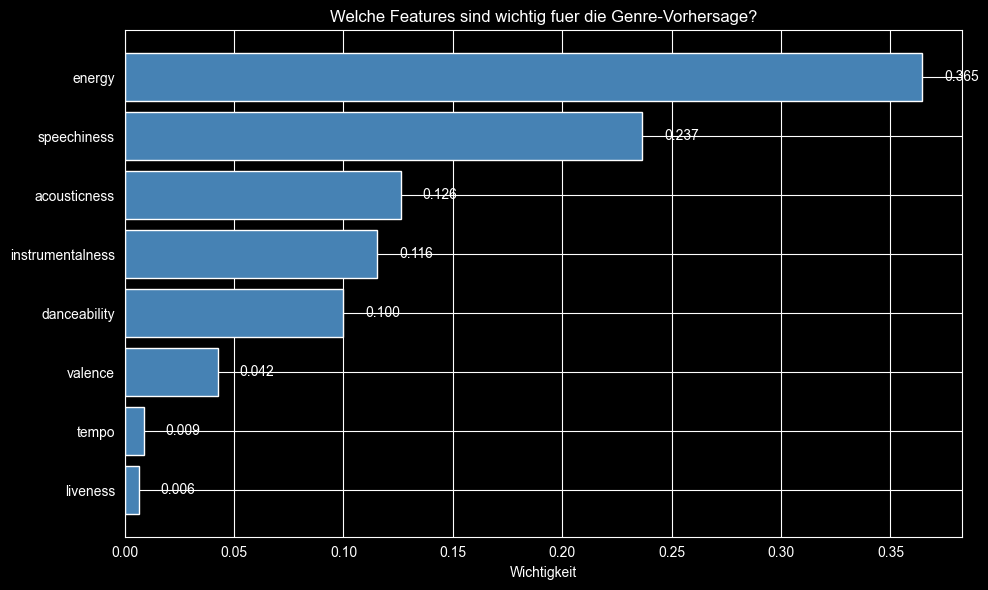


Top 8 wichtigste Features:
  energy: 0.365
  speechiness: 0.237
  acousticness: 0.126
  instrumentalness: 0.116
  danceability: 0.100
  valence: 0.042
  tempo: 0.009
  liveness: 0.006


In [30]:
# Feature-Wichtigkeit visualisieren
importance_df = plot_feature_importance(
    model, 
    feature_columns,
    title='Welche Features sind wichtig fuer die Genre-Vorhersage?'
)

## 9. Decision Tree visualisieren

Schauen wir uns an, wie der Baum Entscheidungen trifft:

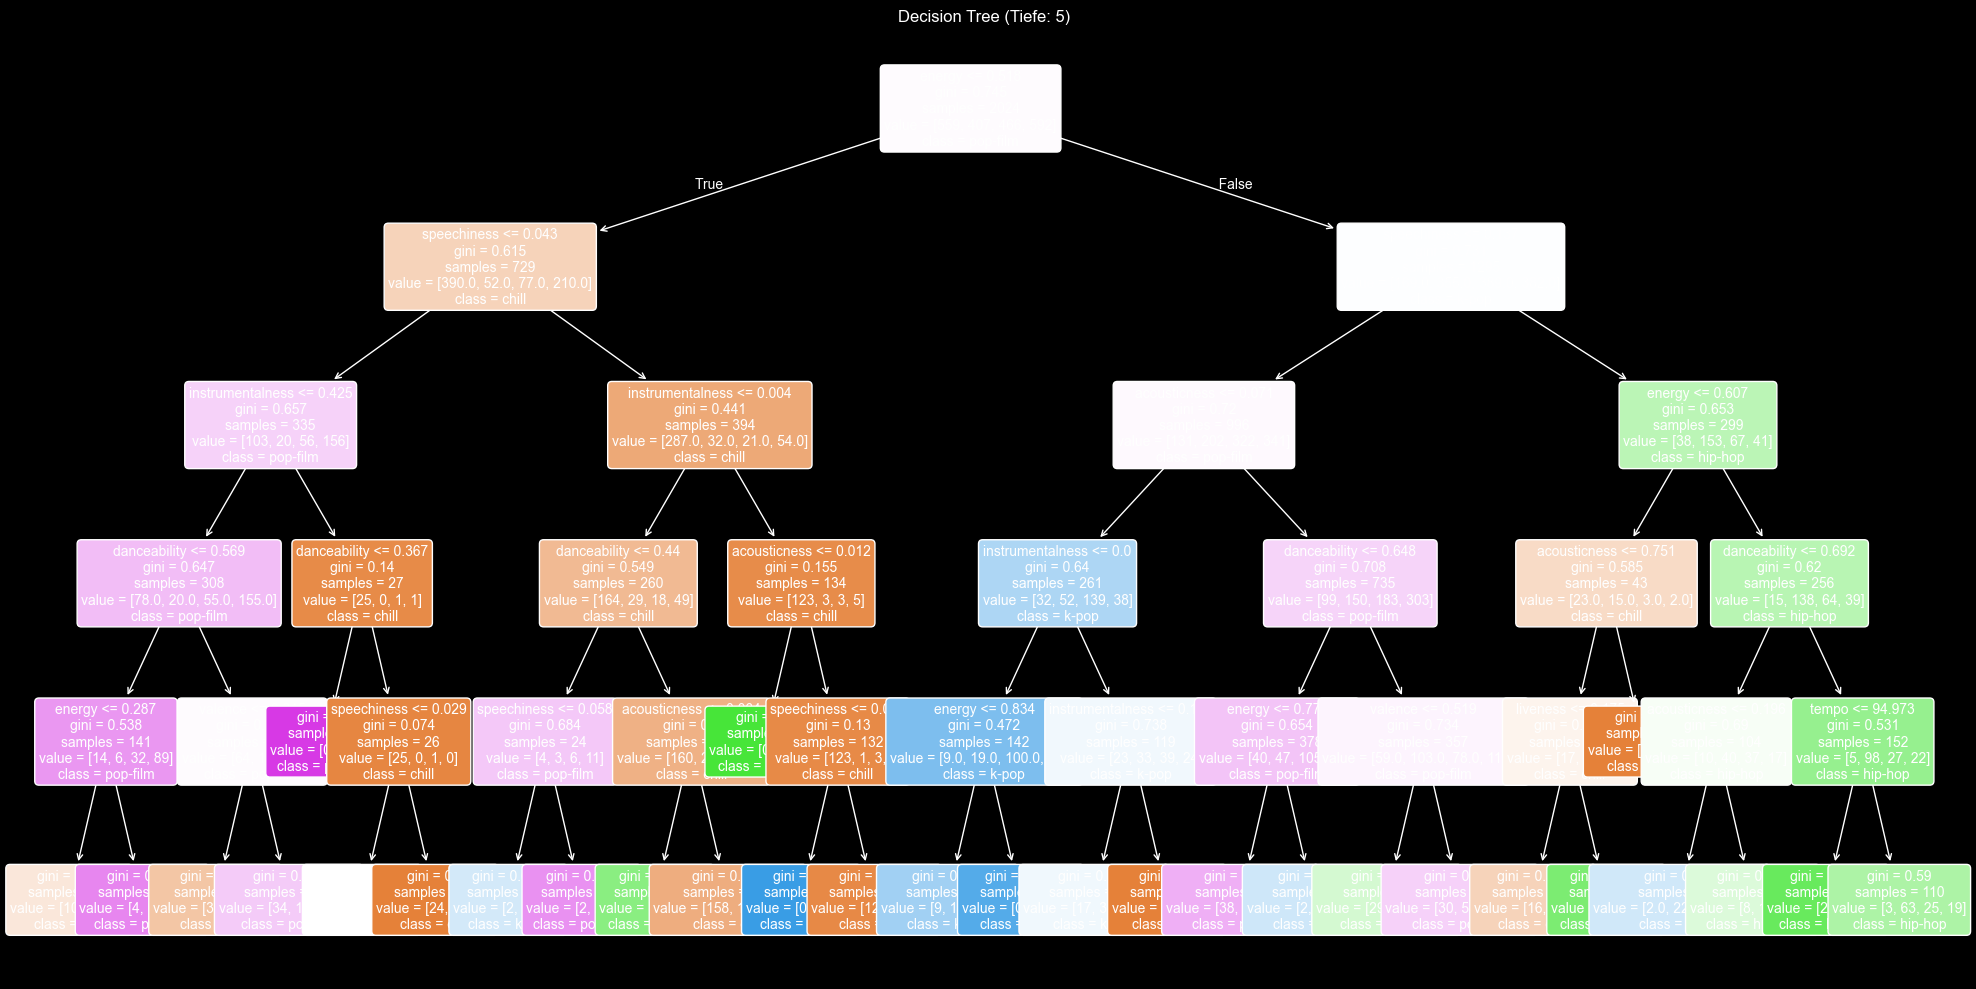

Baum-Visualisierung (zeigt Tiefe 5 von 5 Ebenen)


In [31]:
# Decision Tree visualisieren (nur die ersten 3 Ebenen)
plot_decision_tree(model, feature_columns, max_depth=5)

## 10. Vorhersagen für neue Daten

Jetzt koennen wir das Modell nutzen, um für beliebige Songs das Genre vorherzusagen:

In [43]:
# 5 zufällige Songs auswaehlen
sample_songs = spotify_ml.sample(5, random_state=123)

# Vorhersagen machen
predictions = predict(model, sample_songs, features=feature_columns)

# Ergebnisse anzeigen
result_df = sample_songs[['track_name', 'artists', 'track_genre']].copy()
result_df['vorhersage'] = predictions.values
result_df['richtig'] = result_df['track_genre'] == result_df['vorhersage']

print("Vorhersagen fuer 5 Songs:")
result_df

Vorhersagen gemacht für 5 Datensätze.
Vorhersagen fuer 5 Songs:


,track_name,artists,track_genre,vorhersage,richtig
3484,FELT,Nate Traveller,chill,chill,True
10223,Titli,Satinder Sartaaj,hip-hop,pop-film,False
12019,CLAP,SEVENTEEN,k-pop,k-pop,True
14518,Dilbar,Neha Kakkar;Dhvani Bhanushali;Ikka,pop-film,pop-film,True
3808,True Colours,Tom Odell,chill,chill,True


## 11. Experiment: Random Forest

Ein **Random Forest** ist eine Sammlung von vielen Decision Trees, die zusammen abstimmen. Das ist oft genauer als ein einzelner Baum.

In [44]:
# Random Forest trainieren
rf_model = train_model(X_train, y_train, model_type='random_forest', max_depth=5)

# Bewerten
rf_results = evaluate_model(rf_model, X_test, y_test)

Modell trainiert: Random Forest (max_depth=5, 100 Bäume)
Genauigkeit: 57.1% (57.1% der Songs wurden richtig klassifiziert)

Klassifikationsbericht:
              precision    recall  f1-score   support

       chill       0.73      0.66      0.70       140
     hip-hop       0.51      0.37      0.43       101
       k-pop       0.52      0.42      0.46       117
    pop-film       0.52      0.74      0.61       148

    accuracy                           0.57       506
   macro avg       0.57      0.55      0.55       506
weighted avg       0.58      0.57      0.56       506



In [45]:
# Vergleich: Decision Tree vs Random Forest
print("\n" + "="*50)
print("VERGLEICH DER MODELLE")
print("="*50)
print(f"Decision Tree Genauigkeit: {results['accuracy']:.1%}")
print(f"Random Forest Genauigkeit: {rf_results['accuracy']:.1%}")
print("="*50)


VERGLEICH DER MODELLE
Decision Tree Genauigkeit: 53.6%
Random Forest Genauigkeit: 57.1%


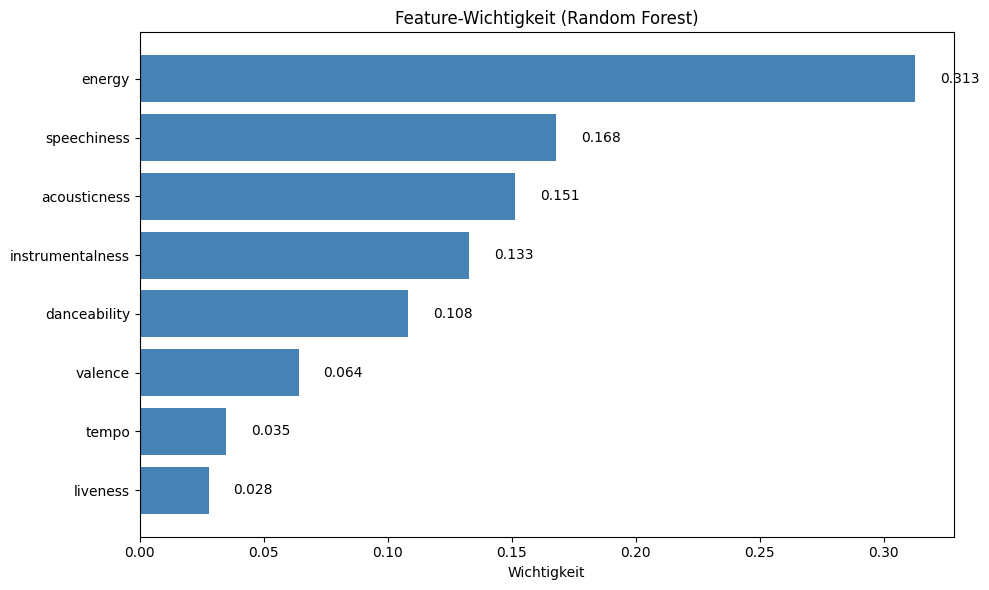


Top 8 wichtigste Features:
  energy: 0.313
  speechiness: 0.168
  acousticness: 0.151
  instrumentalness: 0.133
  danceability: 0.108
  valence: 0.064
  tempo: 0.035
  liveness: 0.028


In [46]:
# Feature-Wichtigkeit des Random Forest
rf_importance = plot_feature_importance(
    rf_model, 
    feature_columns,
    title='Feature-Wichtigkeit (Random Forest)'
)

## 12. Experiment: Mehr Genres

Was passiert, wenn wir mehr Genres hinzufügen? Die Aufgabe wird schwieriger!

In [47]:
# 8 Genres auswählen
more_genres = ['pop-film', 'hip-hop', 'ambient', 'deep-house', 'rock', 'classical', 'jazz', 'electronic']

spotify_8genres = filter_data(spotify, track_genre=more_genres)
print(f"Datensatz mit 8 Genres: {len(spotify_8genres)} Songs")
print(spotify_8genres['track_genre'].value_counts())

Datensatz mit 8 Genres: 2701 Songs
track_genre
pop-film      740
hip-hop       508
deep-house    500
ambient       495
electronic    313
rock           52
jazz           51
classical      42
Name: count, dtype: int64


In [48]:
# ML Pipeline für 8 Genres
X8, y8 = prepare_ml_data(spotify_8genres, target='track_genre', features=feature_columns)
X8_train, X8_test, y8_train, y8_test = split_data(X8, y8)

model_8genres = train_model(X8_train, y8_train, model_type='random_forest', max_depth=7)
results_8genres = evaluate_model(model_8genres, X8_test, y8_test, show_details=False)

Daten vorbereitet: 2701 Datensätze, 8 Features, Ziel: 'track_genre'
Daten aufgeteilt: Training: 2160 (80%), Test: 541 (20%)
Modell trainiert: Random Forest (max_depth=7, 100 Bäume)
Genauigkeit: 64.9% (64.9% der Songs wurden richtig klassifiziert)


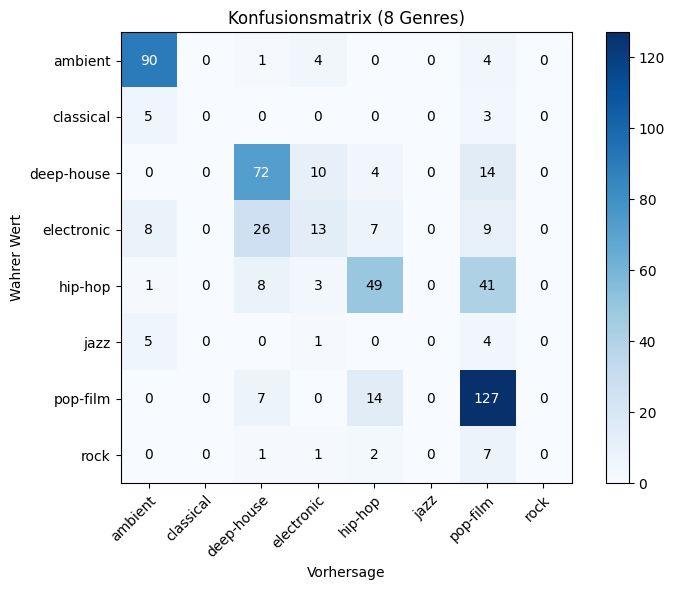

In [49]:
# Konfusionsmatrix für 8 Genres
plot_confusion_matrix(y8_test, results_8genres['predictions'], 
                      title='Konfusionsmatrix (8 Genres)')

## 13. Modellvergleich: Alle 5 Modelltypen

Vergleichen wir verschiedene Machine-Learning-Algorithmen:
- **Decision Tree**: Einzelner Entscheidungsbaum
- **Random Forest**: Ensemble aus vielen Bäumen
- **KNN (K-Nearest Neighbors)**: Klassifiziert basierend auf ähnlichen Datenpunkten
- **SVM (Support Vector Machine)**: Findet optimale Trennebenen
- **Gradient Boosting**: Baut Bäume sequenziell auf, die Fehler korrigieren

In [50]:
# Alle 5 Modelltypen trainieren
models = {
    'Decision Tree': train_model(X_train, y_train, model_type='decision_tree', max_depth=5),
    'Random Forest': train_model(X_train, y_train, model_type='random_forest', max_depth=5),
    'KNN': train_model(X_train, y_train, model_type='knn', n_neighbors=5),
    'SVM': train_model(X_train, y_train, model_type='svm'),
    'Gradient Boosting': train_model(X_train, y_train, model_type='gradient_boosting', max_depth=3)
}

# Genauigkeit für jedes Modell berechnen
accuracies = {}
print("\nModell-Ergebnisse:")
print("-" * 40)
for name, model in models.items():
    model_results = evaluate_model(model, X_test, y_test, show_details=False)
    accuracies[name] = model_results['accuracy']
    print(f"{name}: {model_results['accuracy']:.1%}")

Modell trainiert: Decision Tree (max_depth=5)
Modell trainiert: Random Forest (max_depth=5, 100 Bäume)
Modell trainiert: K-Nearest Neighbors (n_neighbors=5)
Modell trainiert: Support Vector Machine (kernel=rbf)
Modell trainiert: Gradient Boosting (max_depth=3, 100 Bäume)

Modell-Ergebnisse:
----------------------------------------
Genauigkeit: 53.6% (53.6% der Songs wurden richtig klassifiziert)
Decision Tree: 53.6%
Genauigkeit: 57.1% (57.1% der Songs wurden richtig klassifiziert)
Random Forest: 57.1%
Genauigkeit: 41.1% (41.1% der Songs wurden richtig klassifiziert)
KNN: 41.1%
Genauigkeit: 29.2% (29.2% der Songs wurden richtig klassifiziert)
SVM: 29.2%
Genauigkeit: 57.9% (57.9% der Songs wurden richtig klassifiziert)
Gradient Boosting: 57.9%


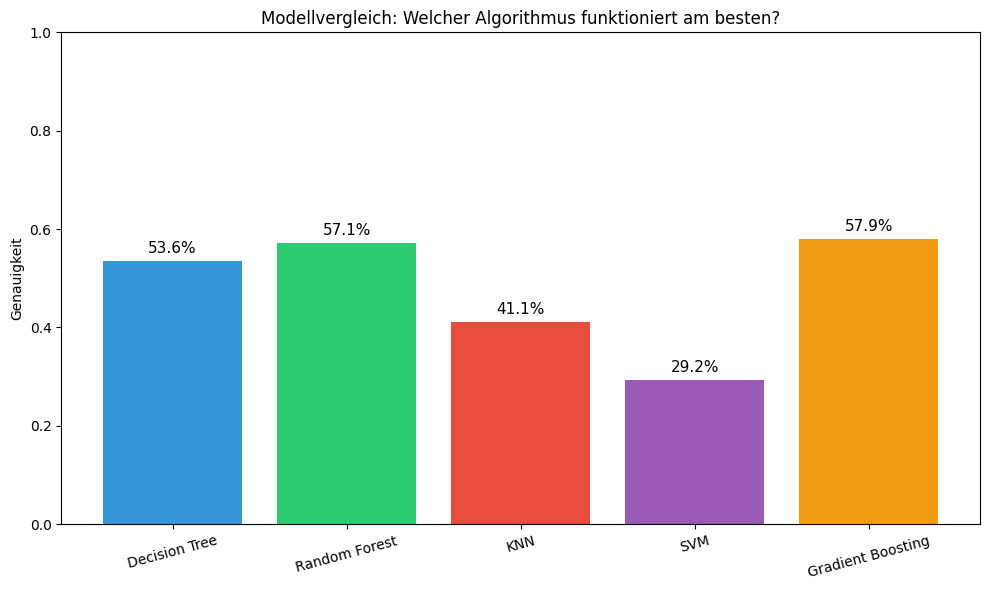

In [51]:
# Balkendiagramm: Modellvergleich
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors)

# Werte über den Balken anzeigen
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.1%}', ha='center', va='bottom', fontsize=11)

plt.ylabel('Genauigkeit')
plt.title('Modellvergleich: Welcher Algorithmus funktioniert am besten?')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 14. PCA: Dimensionsreduktion visualisieren

**PCA (Principal Component Analysis)** reduziert viele Features auf weniger Dimensionen.
Hier projizieren wir unsere 8 Features auf 2 Dimensionen, um sie visualisieren zu koennen.

Das zeigt uns, wie die Genres im Feature-Raum verteilt sind - clustern aehnliche Genres zusammen?

Erklaerte Varianz: 43.3%
  - PC1: 28.4%
  - PC2: 14.9%


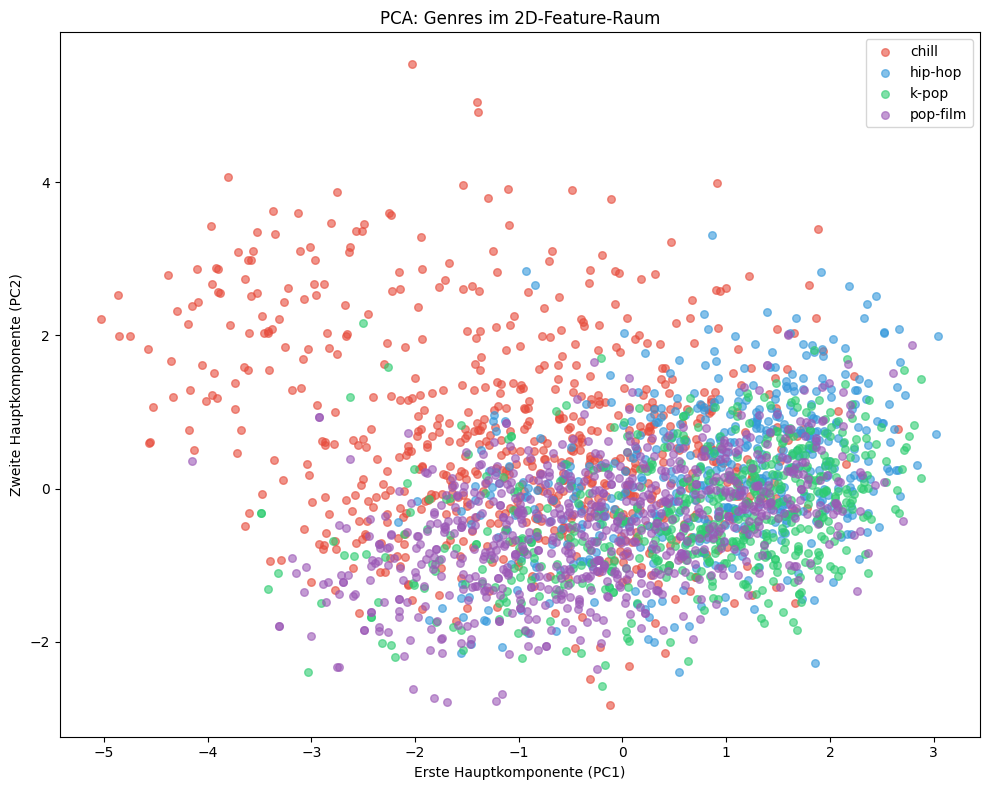

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Features standardisieren (wichtig fuer PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: 8 Features -> 2 Dimensionen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Erklaerte Varianz: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.1%}")

# Scatter Plot mit Genre-Farben
plt.figure(figsize=(10, 8))
genres = y.unique()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for genre, color in zip(genres, colors):
    mask = y == genre
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=color, label=genre, alpha=0.6, s=30)

plt.xlabel('Erste Hauptkomponente (PC1)')
plt.ylabel('Zweite Hauptkomponente (PC2)')
plt.title('PCA: Genres im 2D-Feature-Raum')
plt.legend()
plt.tight_layout()
plt.show()

## 15. Entscheidungsgrenzen visualisieren

Wie "sehen" verschiedene Modelle die Daten? 

Jedes Modell teilt den Feature-Raum auf seine eigene Weise auf. Mit den 2 PCA-Dimensionen koennen wir diese **Entscheidungsgrenzen (Decision Boundaries)** visualisieren.

Modell trainiert: Decision Tree (max_depth=5)
Modell trainiert: Random Forest (max_depth=5, 100 Bäume)
Modell trainiert: K-Nearest Neighbors (n_neighbors=5)
Modell trainiert: Support Vector Machine (kernel=rbf)
Modell trainiert: Gradient Boosting (max_depth=3, 100 Bäume)


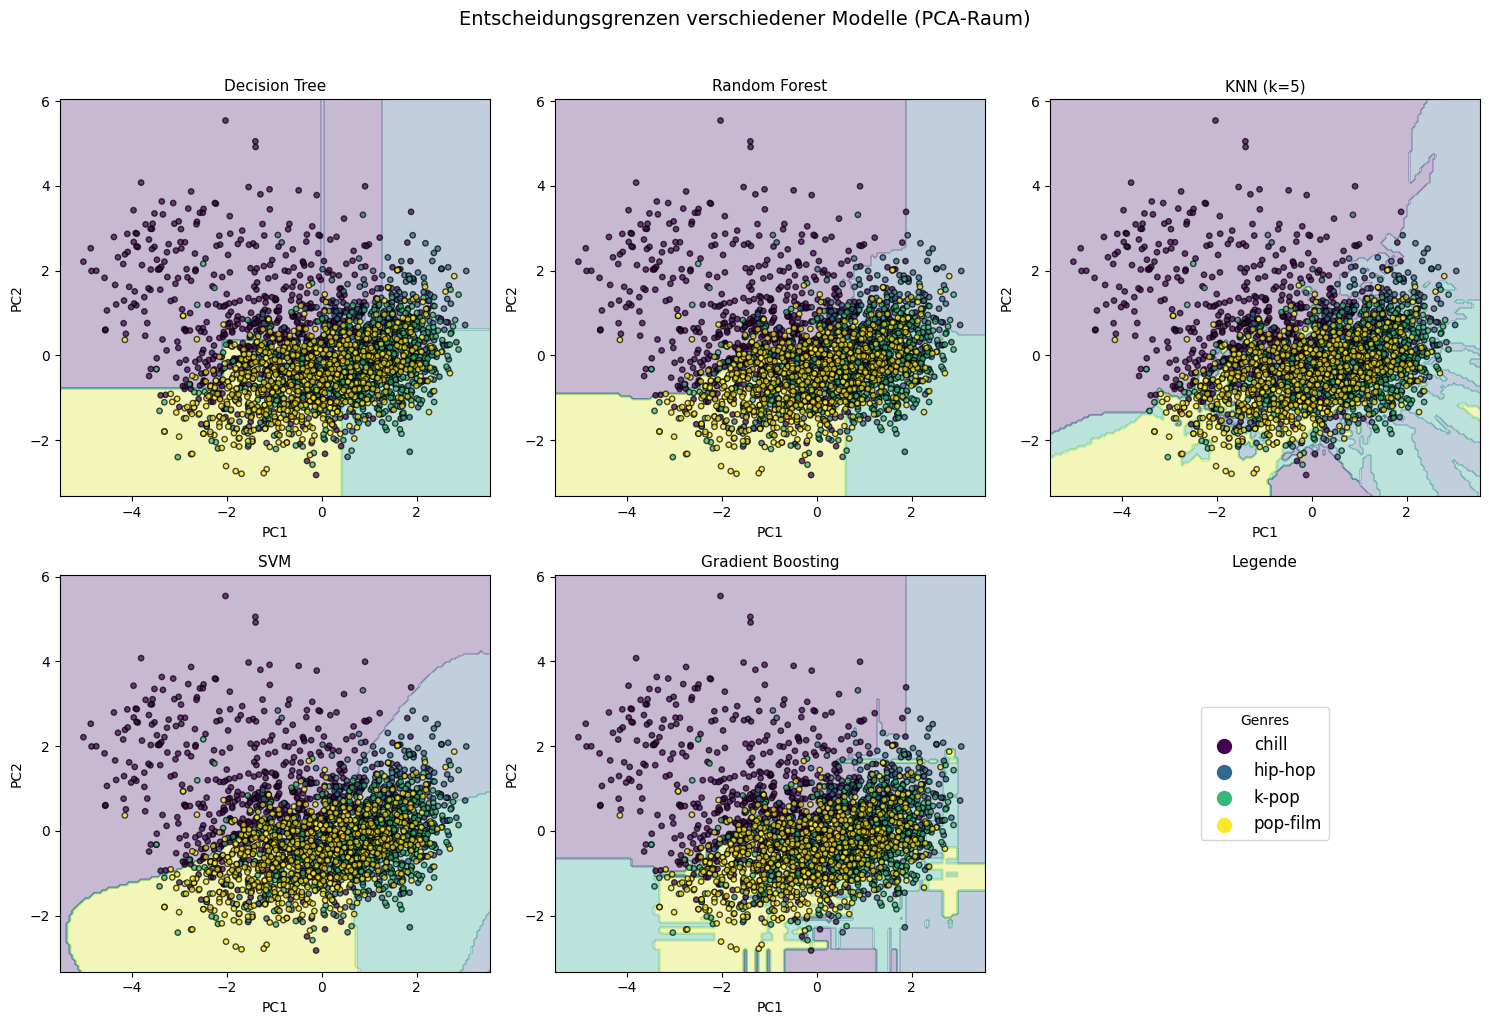

In [53]:
# Funktion zum Plotten der Entscheidungsgrenzen
def plot_decision_boundary(model, X, y, ax, title):
    """Visualisiert die Entscheidungsgrenzen eines Modells."""
    # Mesh-Grid erstellen
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150),
                         np.linspace(y_min, y_max, 150))
    
    # Vorhersagen auf dem Mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    # Konvertiere Klassen zu numerischen Werten
    unique_classes = np.unique(y)
    class_to_num = {c: i for i, c in enumerate(unique_classes)}
    Z_num = np.array([class_to_num[z] for z in Z])
    Z_num = Z_num.reshape(xx.shape)
    
    # Plot
    ax.contourf(xx, yy, Z_num, alpha=0.3, cmap='viridis')
    
    # Datenpunkte
    y_num = np.array([class_to_num[yi] for yi in y])
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_num, cmap='viridis', 
                         edgecolors='black', s=15, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Labels als numerische Werte (fuer Sklearn)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Modelle auf PCA-Daten trainieren
pca_models = {
    'Decision Tree': train_model(X_pca, y, model_type='decision_tree', max_depth=5),
    'Random Forest': train_model(X_pca, y, model_type='random_forest', max_depth=5),
    'KNN (k=5)': train_model(X_pca, y, model_type='knn', n_neighbors=5),
    'SVM': train_model(X_pca, y, model_type='svm'),
    'Gradient Boosting': train_model(X_pca, y, model_type='gradient_boosting', max_depth=3)
}

# 2x3 Subplot-Grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, pca_model) in enumerate(pca_models.items()):
    plot_decision_boundary(pca_model, X_pca, y.values, axes[idx], name)

# Letztes Subplot für Legende
axes[5].axis('off')
genres_unique = y.unique()
colors_legend = plt.cm.viridis(np.linspace(0, 1, len(genres_unique)))
for genre, color in zip(genres_unique, colors_legend):
    axes[5].scatter([], [], c=[color], label=genre, s=100)
axes[5].legend(loc='center', fontsize=12, title='Genres')
axes[5].set_title('Legende', fontsize=11)

plt.suptitle('Entscheidungsgrenzen verschiedener Modelle (PCA-Raum)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Zusammenfassung

**Was wir gelernt haben:**

1. **Daten vorbereiten**: Features (X) und Zielvariable (y) trennen
2. **Train/Test Split**: Daten aufteilen, um das Modell fair zu testen
3. **Modell trainieren**: Decision Tree oder Random Forest
4. **Bewerten**: Genauigkeit und Konfusionsmatrix analysieren
5. **Interpretieren**: Feature-Wichtigkeit zeigt, was das Modell gelernt hat

**Naechste Schritte zum Ausprobieren:**
- Andere Genres auswaehlen
- Andere Features verwenden
- max_depth veraendern
- Mit den Olympics- oder Movies-Daten experimentieren